# 📊 Unemployment Analysis with Python

Analyzing unemployment rate data in India, cleaning and exploring it, visualizing trends, and quantifying the impact of COVID-19.

**Data source:** CodeAlpha Data Science Internship Task (`Unemployment in India.csv`, `Unemployment_Rate_upto_11_2020.csv`)

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

COVID_START = pd.Timestamp("2020-03-01")

## 2. Load Dataset

In [2]:
df_main_raw = pd.read_csv("data/Unemployment in India.csv")
df_2020_raw = pd.read_csv("data/Unemployment_Rate_upto_11_2020.csv")

df_main_raw.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df_2020_raw.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Data Cleaning

Strip column-name whitespace, drop fully-empty trailing rows, parse dates, drop duplicates, and rename the duplicated `Region` (zone) column in the 2020 dataset.

In [4]:
def clean_main(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.dropna(how="all")
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
    df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")
    df = df.drop_duplicates()
    return df.sort_values("Date").reset_index(drop=True)

def clean_2020(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.dropna(how="all")
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
    df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")
    df = df.rename(columns={"Region.1": "Zone"})
    df = df.drop_duplicates()
    return df.sort_values("Date").reset_index(drop=True)

df_main = clean_main(df_main_raw)
df_2020 = clean_2020(df_2020_raw)

print("df_main:", df_main.shape, " missing:", df_main.isnull().sum().sum())
print("df_2020:", df_2020.shape, " missing:", df_2020.isnull().sum().sum())

df_main: (740, 7)  missing: 0
df_2020: (267, 9)  missing: 0


## 4. Exploratory Data Analysis (EDA)

In [5]:
df_main.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [6]:
df_main["Region"].nunique(), df_main["Date"].min(), df_main["Date"].max()

(28, Timestamp('2019-05-31 00:00:00'), Timestamp('2020-06-30 00:00:00'))

In [7]:
df_main[["Estimated Unemployment Rate (%)", "Estimated Employed",
         "Estimated Labour Participation Rate (%)"]].corr()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


## 5. Data Visualization

### Monthly Unemployment Trend

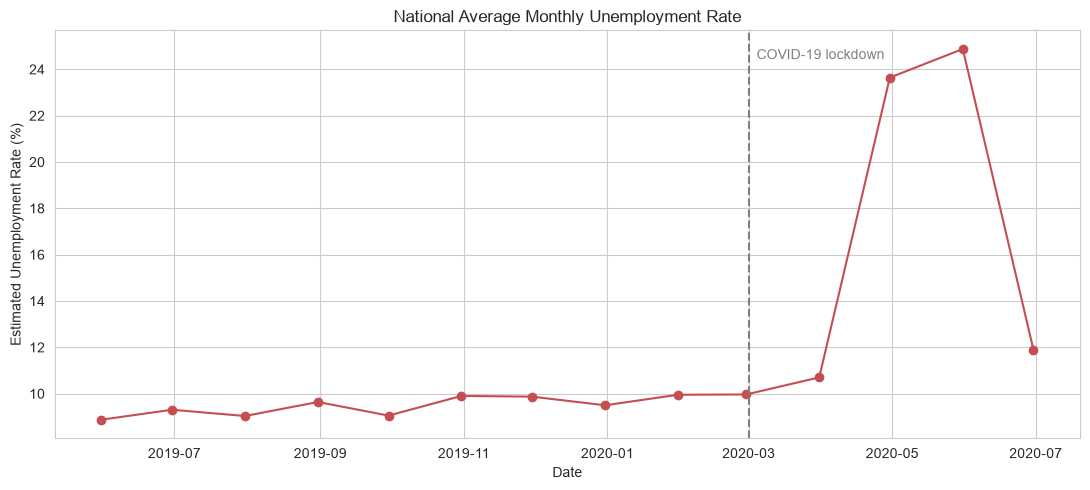

In [8]:
monthly = df_main.groupby("Date")["Estimated Unemployment Rate (%)"].mean().reset_index()

plt.figure(figsize=(11, 5))
plt.plot(monthly["Date"], monthly["Estimated Unemployment Rate (%)"], marker="o", color="#c44e52")
plt.axvline(COVID_START, color="gray", linestyle="--")
plt.text(COVID_START, monthly["Estimated Unemployment Rate (%)"].max(),
         "  COVID-19 lockdown", va="top", color="gray")
plt.title("National Average Monthly Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.tight_layout()
plt.show()

### State-wise Average Unemployment Rate

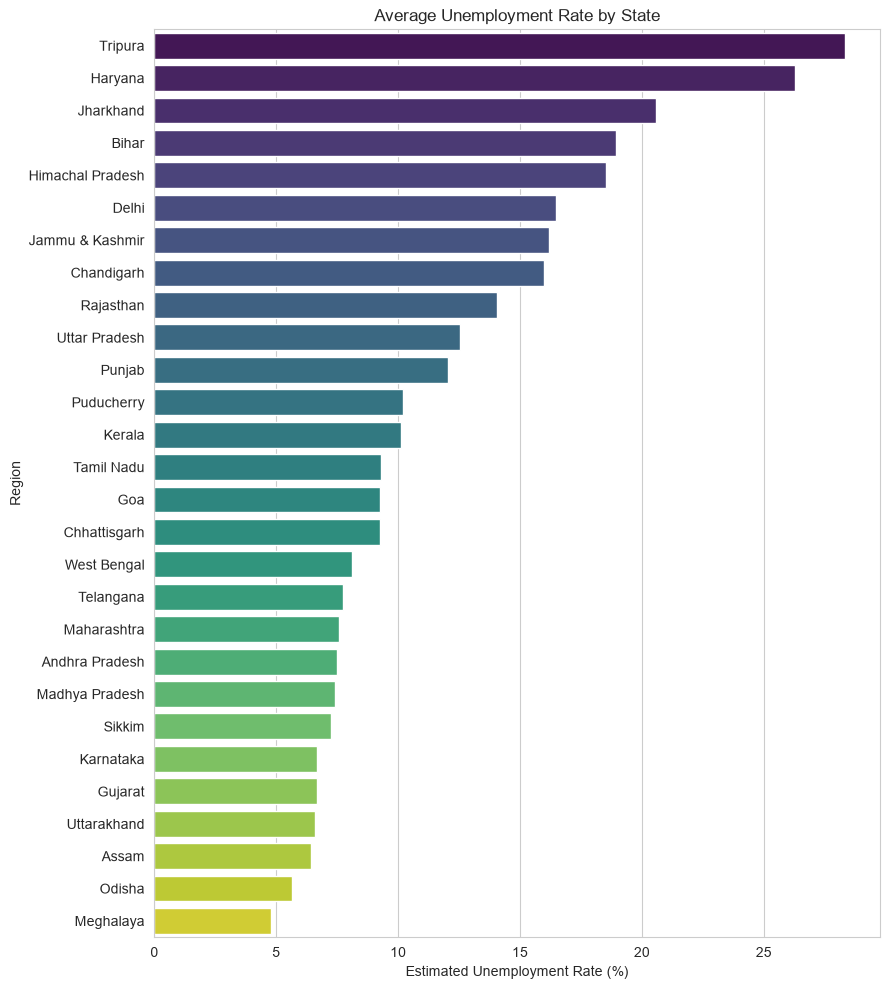

In [9]:
state_avg = df_main.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 10))
sns.barplot(x=state_avg.values, y=state_avg.index, hue=state_avg.index, palette="viridis", legend=False)
plt.title("Average Unemployment Rate by State")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.tight_layout()
plt.show()

### Distribution of Unemployment Rate

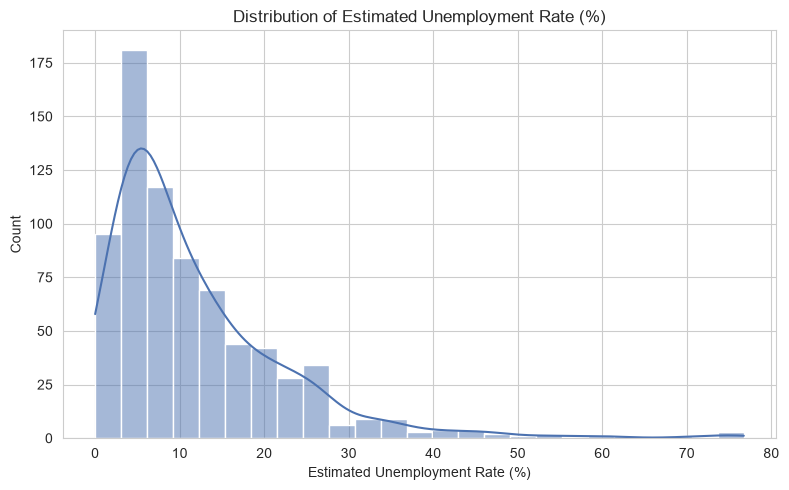

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df_main["Estimated Unemployment Rate (%)"], bins=25, kde=True, color="#4C72B0")
plt.title("Distribution of Estimated Unemployment Rate (%)")
plt.tight_layout()
plt.show()

### Correlation Heatmap

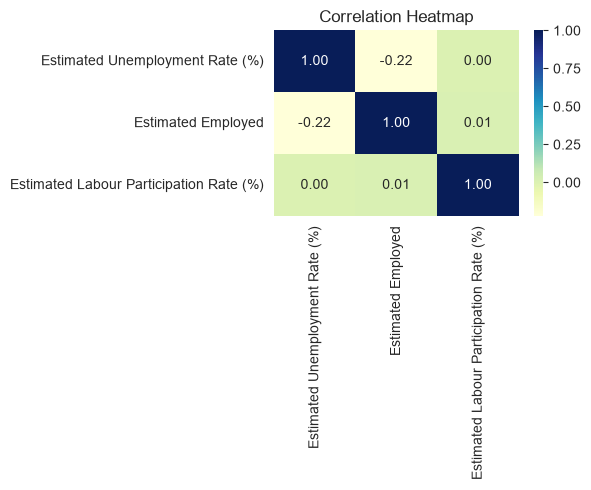

In [11]:
numeric_cols = ["Estimated Unemployment Rate (%)", "Estimated Employed",
                "Estimated Labour Participation Rate (%)"]
plt.figure(figsize=(6, 5))
sns.heatmap(df_main[numeric_cols].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Box Plot: Rural vs Urban

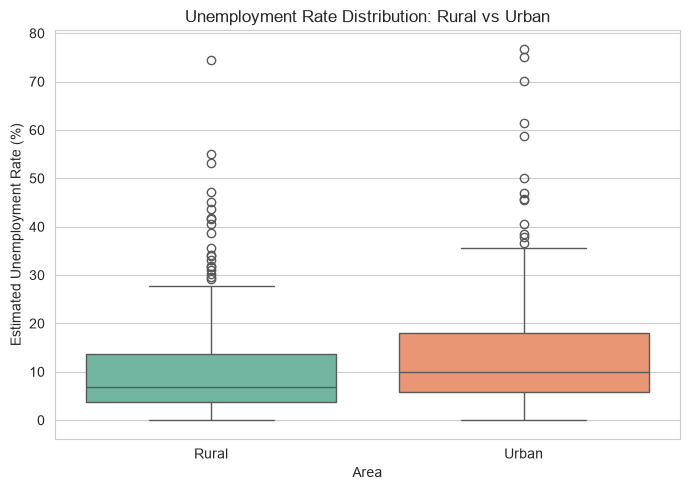

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_main, x="Area", y="Estimated Unemployment Rate (%)", hue="Area", palette="Set2", legend=False)
plt.title("Unemployment Rate Distribution: Rural vs Urban")
plt.tight_layout()
plt.show()

### Zone-wise Unemployment Rate (2020 dataset)

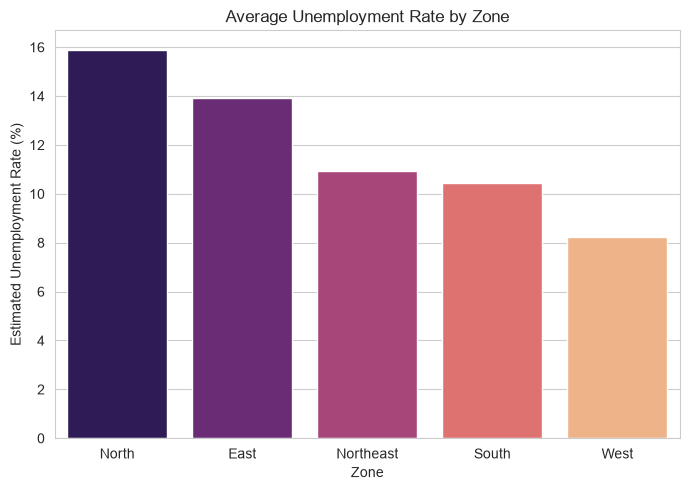

In [13]:
zone_avg = df_2020.groupby("Zone")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=zone_avg.index, y=zone_avg.values, hue=zone_avg.index, palette="magma", legend=False)
plt.title("Average Unemployment Rate by Zone")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.tight_layout()
plt.show()

## 6. COVID-19 Impact Analysis

In [14]:
df = df_main.copy()
df["Period"] = np.where(df["Date"] < COVID_START, "Pre-COVID", "COVID")

period_avg = df.groupby("Period")["Estimated Unemployment Rate (%)"].mean()
period_avg

Period
COVID        17.774363
Pre-COVID     9.509534
Name: Estimated Unemployment Rate (%), dtype: float64

In [15]:
state_period = df.groupby(["Region", "Period"])["Estimated Unemployment Rate (%)"].mean().unstack()
state_period["Change (pp)"] = state_period["COVID"] - state_period["Pre-COVID"]
state_period = state_period.sort_values("Change (pp)", ascending=False)

print("Most affected states:")
display(state_period.head(5))

print("Least affected / improved states:")
display(state_period.tail(5))

Most affected states:


Period,COVID,Pre-COVID,Change (pp)
Region,,,
Puducherry,38.95500,1.5930,37.36200
Tamil Nadu,25.40375,2.8365,22.56725
Jharkhand,36.34875,14.2795,22.06925
Bihar,31.63125,13.8330,17.79825
Karnataka,15.28000,3.2345,12.04550


Least affected / improved states:


Period,COVID,Pre-COVID,Change (pp)
Region,,,
Assam,6.578571,6.372632,0.20594
Chandigarh,14.325000,16.325000,-2.00000
Himachal Pradesh,17.068750,19.129000,-2.06025
Tripura,26.702500,29.009500,-2.30700
Jammu & Kashmir,12.888000,17.220000,-4.33200


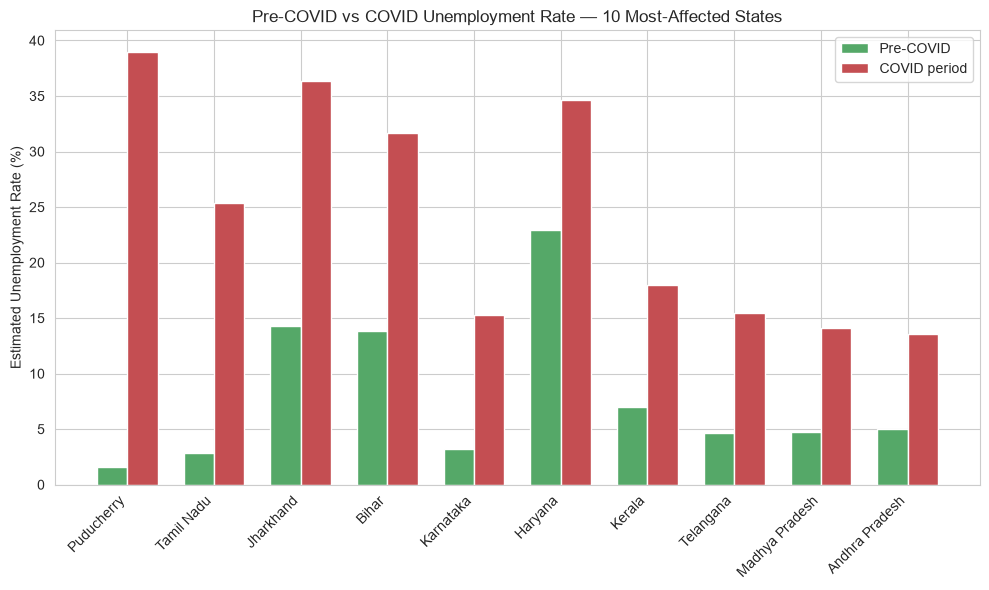

In [16]:
top10 = state_period.head(10)
x = np.arange(len(top10))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, top10["Pre-COVID"], width, label="Pre-COVID", color="#55a868")
plt.bar(x + width/2, top10["COVID"], width, label="COVID period", color="#c44e52")
plt.xticks(x, top10.index, rotation=45, ha="right")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.title("Pre-COVID vs COVID Unemployment Rate — 10 Most-Affected States")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
lp_period = df.groupby("Period")["Estimated Labour Participation Rate (%)"].mean()
lp_period

Period
COVID        39.330049
Pre-COVID    43.886119
Name: Estimated Labour Participation Rate (%), dtype: float64

## 7. Insights & Conclusions

In [18]:
increase = period_avg["COVID"] - period_avg["Pre-COVID"]
most_affected = state_period["Change (pp)"].idxmax()
most_affected_val = state_period["Change (pp)"].max()

print(f"1. National unemployment rose from {period_avg['Pre-COVID']:.2f}% to "
      f"{period_avg['COVID']:.2f}% ({increase:.2f} pp increase) after COVID-19 hit.")
print(f"2. {most_affected} was the most-affected region, up {most_affected_val:.2f} pp.")
print(f"3. {zone_avg.index[0]} zone had the highest average unemployment rate in 2020 "
      f"({zone_avg.iloc[0]:.2f}%), {zone_avg.index[-1]} the lowest ({zone_avg.iloc[-1]:.2f}%).")
print("4. Unemployment spiked sharply in April-May 2020 during the nationwide lockdown, "
      "then began recovering in subsequent months.")

1. National unemployment rose from 9.51% to 17.77% (8.26 pp increase) after COVID-19 hit.
2. Puducherry was the most-affected region, up 37.36 pp.
3. North zone had the highest average unemployment rate in 2020 (15.89%), West the lowest (8.24%).
4. Unemployment spiked sharply in April-May 2020 during the nationwide lockdown, then began recovering in subsequent months.
